<a href="https://colab.research.google.com/github/pras73/soma-gen/blob/main/Copy_of_AIML_PrasannaDharmavarapu_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [ ]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

**Note**:

1. *After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.*

2. *On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.*

## Loading the dataset

In [ ]:
# running this as the Dataset is present in Google Drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
asset_customers = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Week2-MachineLearning_Decisiontrees/Project2_DecisionTree/Loan_Modelling.csv")

In [ ]:
# creating a copy of the data named "loan_customers" to preserve the original copy without changes for future reference
loan_customers = asset_customers.copy()

## Data Overview

**Examining the first 5 rows and last 5 rows of loan_customers Data set**

In [ ]:
# examining the first 5 rows of the Dataset
loan_customers.head(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


**Observations**

 *No discrepancies observed in first 5 rows of the Dataset.*

In [ ]:
# examining the last 5 rows of the Dataset
loan_customers.tail(5)

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


**Observations**

 *No discrepancies observed in last 5 rows of the Dataset.*

**Checking the shape of the Dataset**

In [ ]:
# checking the shape of Dataset(Number of rows and columns in the Dataset)
num_rows = loan_customers.shape[0]
num_columns = loan_customers.shape[1]
print(f"The Dataset has {num_rows} rows and {num_columns} columns.")

The Dataset has 5000 rows and 14 columns.


**Observations:**

*The Dataset has 5000 rows and 14 columns.*

**Checking the attribute types**

In [ ]:
# checking the attribute types in the Dataset
loan_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


**Observations:**

* *There are 14 numerical variables in the data.*
* *ZIPCode, Education, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard although interpreted here as numerical, are categorical variables that are encoded by default.*



**Checking Statistical Summary of the Dataset**

In [ ]:
# checking statistical summary of the Data, applying Transpose for easier read
loan_customers.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


**Observations:**

* *Average age of the Customer is approximately 45 years with minimum age of 23 years and maximum age of 67 years. Data seems to be normaly distributed.*

* *Minimum professional experience is showing as -3 which seems to be unrealistic number for professional experience, it could be a typo or manual calculation error. Need to research further.*

* *Income ranges from 8,000 TO 224,000 in USD with an average income of approximately 74K in dollars. 50% of customers have incomes of 64,000 in dollars and above. Data seems to be right skewed.*

* *The average family size is 2 with 50% of customers having a family size of 2 and above,almost uniformly distributed.*

* *The average spending on credit cards is approximately 2,000 in dollars per month.*

* *The average value of mortgages is approximately 56,000 in dollars where 75% of the customers mortgage value is showing around 100,000 in dollars and max value of mortgage is showing as 635,000 in dollars. It looks there are Outliers.Data seems to be right skewed.*

* *Education, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard statistics could not be interpreted clearly as they are classification attributes as oppose to numerical attributes. EDA analayis to be done to have a clear picture of each.*

**Checking for missing values**

In [ ]:
# checking for null values
loan_customers.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


**Observations:**

*There are no missing values in the dataset.*

**Checking for duplicate values**

In [ ]:
# checking for duplicate values
dup_rows_count = loan_customers.duplicated().sum()
print(f"Count of Duplicate rows: {dup_rows_count}", "\n")

dup_rows = loan_customers.loc[loan_customers.duplicated()]
print(f"Duplicate rows:\n{dup_rows}")

Count of Duplicate rows: 0 

Duplicate rows:
Empty DataFrame
Columns: [ID, Age, Experience, Income, ZIPCode, Family, CCAvg, Education, Mortgage, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard]
Index: []


**Observations**

*There are no Duplicates in the Dataset.*

## Data Preprocessing

**Dropping the ID column**

*Dropping ID column as it is not essential for further analysis*

In [ ]:
#Dropping the ID column because it is not essential for bivariate analysis
loan_customers.drop("ID", axis=1, inplace=True)

***Examining "Experience" column where we noticed negative value for min value in Statistical summary***

***As a first step trying to find if there are any other numeric columns in the Dataset having negative values other than in "Experience" column which does not feel realistic***

In [ ]:
# To find which numeric columns in the Dataset have negatives
negatives_by_column = (loan_customers.select_dtypes(include= "number") < 0).any()
print(negatives_by_column)

Age                   False
Experience             True
Income                False
ZIPCode               False
Family                False
CCAvg                 False
Education             False
Mortgage              False
Personal_Loan         False
Securities_Account    False
CD_Account            False
Online                False
CreditCard            False
dtype: bool


**Observations**

*Only Experience column has negative values. Need to check how many rows in Dataset with negative values.*

***Next step is to find number of rows with negative values in Experience column***

In [ ]:
# To find number of rows with negative values in Experience column
num_rows = (loan_customers["Experience"] < 0).sum()
print(f"There are {num_rows} rows with negative values in Experience column.")

There are 52 rows with negative values in Experience column.


**Observations:**

*There are 52 rows with negative values in Experience column. Need to treat these negative values before proceeding to Model building.*

***Examining the Distribution of Experience column to figure out if the negative values need to be treated by inputting Mean, Median or Mode***

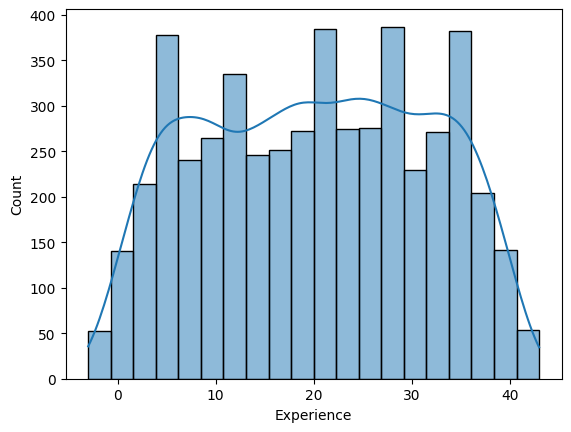

In [ ]:
# plot the distribution of the Experience variable to examine the skeweness to decide on the best imputation method
sns.histplot(x=loan_customers["Experience"], kde=True);

**Observations:**

*Distribution is roughly taking a bell shaped curve(uniformly distributed), so will take the approach of treating negative values by inputting with Median.*

***Treating negative values in Experience column with Median***

In [ ]:
# treating negative values in Experience column with Median
loan_customers["Experience"] = loan_customers["Experience"].apply(
    lambda x: loan_customers["Experience"].median() if x < 0 else x
)

In [ ]:
# checking the value counts to confirm imputation is successful
print(f"There are {len(loan_customers[loan_customers["Experience"] < 0])} rows with negative values in Experience column. Imputation worked.")

There are 0 rows with negative values in Experience column. Imputation worked.


**Observations**

*There are 0 rows with negative values in Experience column. Imputation worked.*

**"ZIPCode" column treatment**

*The ZIP code column has to be treated so that it can be analysed as a categorical variable rather than numerical variable. It is not a continuous number and should be treated so that customers can be grouped based on their geographic location.*

**Note:** *For translation will be using **pgeocode** package to extract information about each ZIP Code and then the ZIP Code will be categorized based on geographic region.*

In [ ]:
!pip install pgeocode

In [ ]:
import pgeocode

# initializing geocoder for USA
nomi = pgeocode.Nominatim("us")

**Comments:**

*Initialized geocoder for USA.Next step is to extract the County name for all the entries in the ZIPCode column and add the results in a new column. I am going by county_name so as to get smaller bucket for categorizing as oppose to city or place name*

In [ ]:
# Extracting the County name for all the entries in the ZIPCode column and add the results to new "County" column
loan_customers["County"] = loan_customers["ZIPCode"].apply(lambda x: nomi.query_postal_code(x).county_name)
loan_customers["State"] = loan_customers["ZIPCode"].apply(lambda x: nomi.query_postal_code(x).state_name)

In [ ]:
# viewing first 5 rows after adding the "County" name column
loan_customers.head()

,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,County,State
0,25,1.0,49,91107,4,1.6,1,0,0,1,0,0,0,Los Angeles,California
1,45,19.0,34,90089,3,1.5,1,0,0,1,0,0,0,Los Angeles,California
2,39,15.0,11,94720,1,1.0,1,0,0,0,0,0,0,Alameda,California
3,35,9.0,100,94112,1,2.7,2,0,0,0,0,0,0,City and County of San Francisco,California
4,35,8.0,45,91330,4,1.0,2,0,0,0,0,0,1,Los Angeles,California


**Comments**

*"County" column is added to loan_customers Data set.*

In [ ]:
# finding any null values in "County" column after the Zipcode translation
county_with_null_values = loan_customers["County"].isnull().sum()
print(f"There are {county_with_null_values} rows with null values in County column.")


There are 41 rows with null values in County column.


**Observations**

*There are 41 rows with null values in County column.*

In [ ]:
from os import stat_result
county_unique = loan_customers["County"].unique()
state_unique = loan_customers["State"].unique()
print(f"Unique values in State column: {state_unique}." ,"\n")
print(f"Unique values in County column: {county_unique}." ,"\n")
print(f"There are {len(county_unique)} unique values in County column.")


Unique values in State column: ['California' nan]. 

Unique values in County column: ['Los Angeles' 'Alameda' 'City and County of San Francisco' 'San Diego'
 'Monterey' 'Ventura' 'Santa Barbara' 'Marin' 'Santa Clara' 'Santa Cruz'
 'San Mateo' 'Humboldt' 'Contra Costa' 'Orange' 'Sacramento' 'Yolo'
 'Placer' 'San Bernardino' 'San Luis Obispo' 'Riverside' 'Kern' nan
 'Fresno' 'Sonoma' 'El Dorado' 'San Benito' 'Butte' 'Solano' 'Mendocino'
 'San Joaquin' 'Imperial' 'Siskiyou' 'Merced' 'Trinity' 'Stanislaus'
 'Shasta' 'Tuolumne' 'Napa' 'Lake']. 

There are 39 unique values in County column.


**Observations:**

*There are 39 unique values for County in the State of California.*

In [ ]:
# finding number of zip codes with no assigned county
county_null = loan_customers[loan_customers["County"].isnull()]
county_null["ZIPCode"].value_counts()
print(f"There are {len(county_null["ZIPCode"].value_counts())} Zip codes with no assigned County." ,"\n")

There are 5 Zip codes with no assigned County. 



**Observations:**

*There are 5 Zip codes with no assigned County and State.*

In [ ]:
# finding zip codes with no assigned county
county_null["ZIPCode"].value_counts()

,count
ZIPCode,
92717,22
92709,7
96651,6
92634,5
93077,1


**Observations**

*Planning to leave all 41 rwos with no values in County and State column as such with "NaN".

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

**Univariate Analysis**

***Grouping features Age, Experience, Income, CCAvg and Mortgage for univariate analysis for values that are continous in nature***

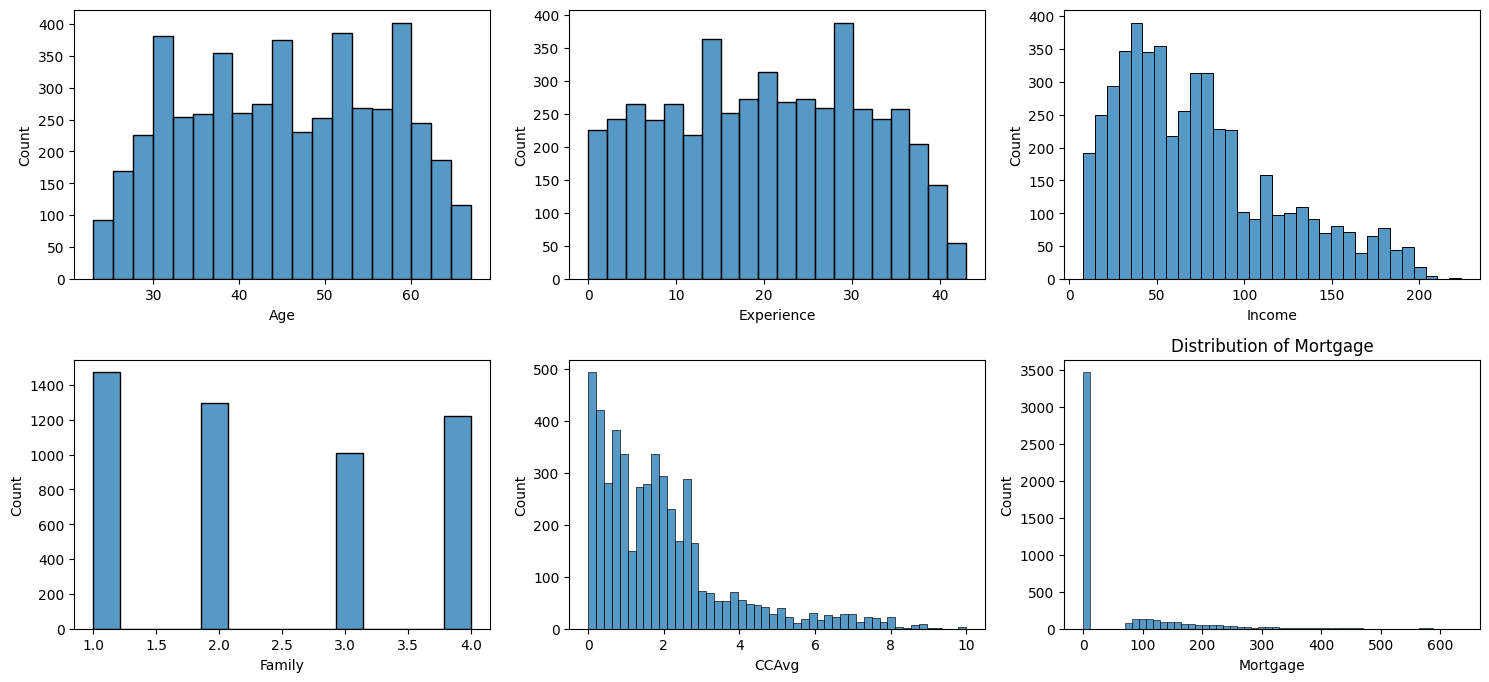

In [ ]:
# plotting histogram for the features selected
plt.figure(figsize=(15,10))
continous_features = ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage"]

for i, feature in enumerate(continous_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(data=loan_customers, x=feature)
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.tight_layout()
plt.show()

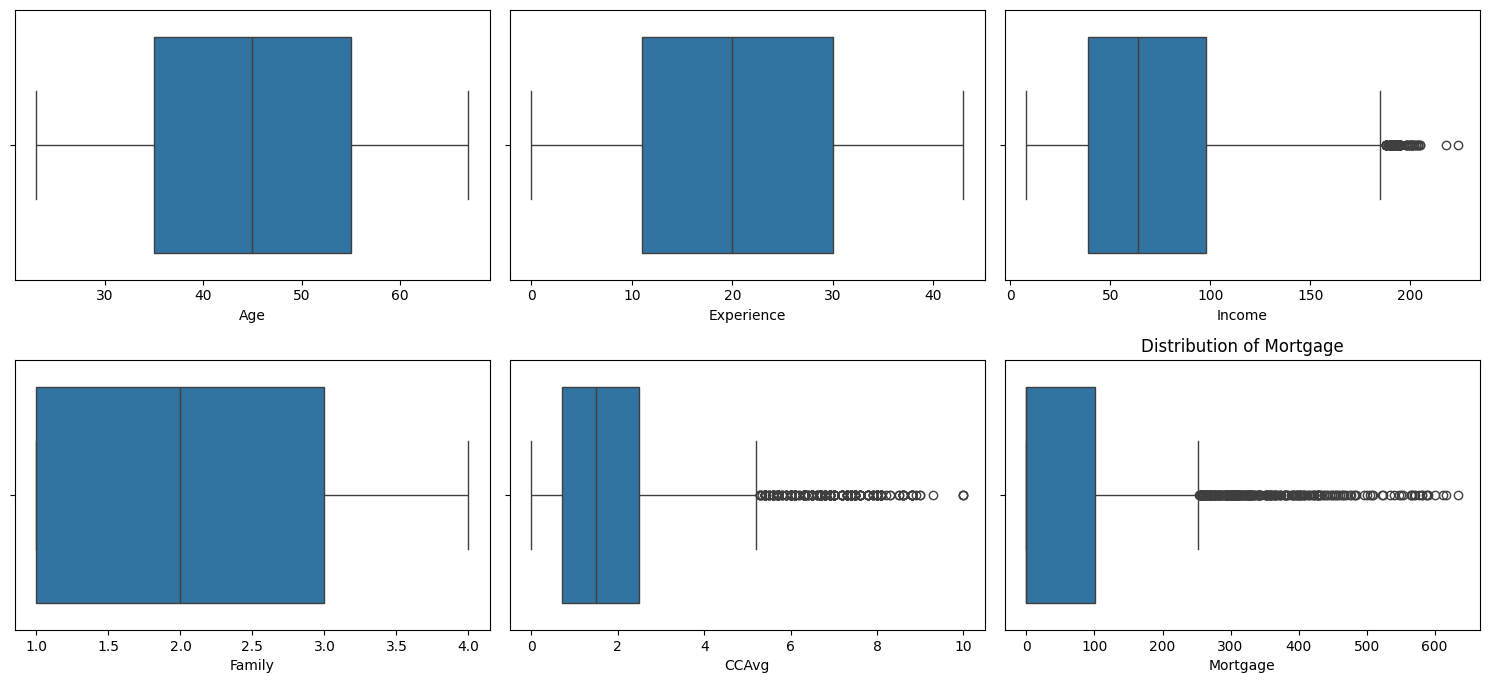

In [ ]:
# plotting boxplot for the features selected
plt.figure(figsize=(15,10))
continous_features = ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage"]

for i, feature in enumerate(continous_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(data=loan_customers, x=feature)
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.tight_layout()
plt.show()

**Observations for Age feature**

* *The min is 23 , max is 67 , Average is 45 Years old, Data is close to normal distribution.*
* *The maximum number of customers is within the 58-60 years range, there are peak counts at 30-32, 38-40, 44-46 and 52-54 years and there are no ouliers observed.*

**Observations for Experience feature**

* *Min Experience is 0 years, max is 43 years and the mean is approximately 20 years.*
* *Data seems close to normal distribution with peaks at 12-14 years and 28-30 years and there are no outliers observed.*

**Observations for Income feature**

* *Min Income is 46,000 in dollars, max is 224,000 in dollars and average is 64,000 in dollars, Data seems slightly right skewed. There are outliers observed, but seems consistent with data hence no action is required.*

**Observations for CCAvg feature**

* *Min CCAvg is 0 dollars ( could be interpreted as customers who do not own credit cards), max is 1900 in dollars and average is approximately 1900 in dollars.*
* *Dataset is right skewed with number of outliers that seem homogenous with the data, hence no action required for the outliers.*

**Observations for Mortgage feature**

* *Min Mortgage is 0 dollars, max is 635,000 dollars and average is 0 dollars.Data is heavily right skewed with number of outliers that seem homogenous with the data, hence no action required for the outliers. Let examine more on this column as the data seems to be showing not many customers have mortgage.*

***Examining Mortgage feature more so we could see how many customers have mortgage***

In [ ]:
#extracting the customers with mortgage values > 0
mortgage_cust_num = loan_customers[loan_customers["Mortgage"]>0]
percentage = (len(mortgage_cust_num) / len(loan_customers)) * 100
print(f"There are {len(mortgage_cust_num)} customers in the Dataset having mortgage which contributes for {round(percentage)} % of the Dataset.")

There are 1538 customers in the Dataset having mortgage which contributes for 31 % of the Dataset.


**Observations:**

*There are 1538 customers in the Dataset having mortgage which contributes for 31 % of the Dataset.*

***Plotting histogram for the distribution of customers who have mortgage(mortgage > 0) to get better picture***

Mean of Mortgage: 183.67620286085827


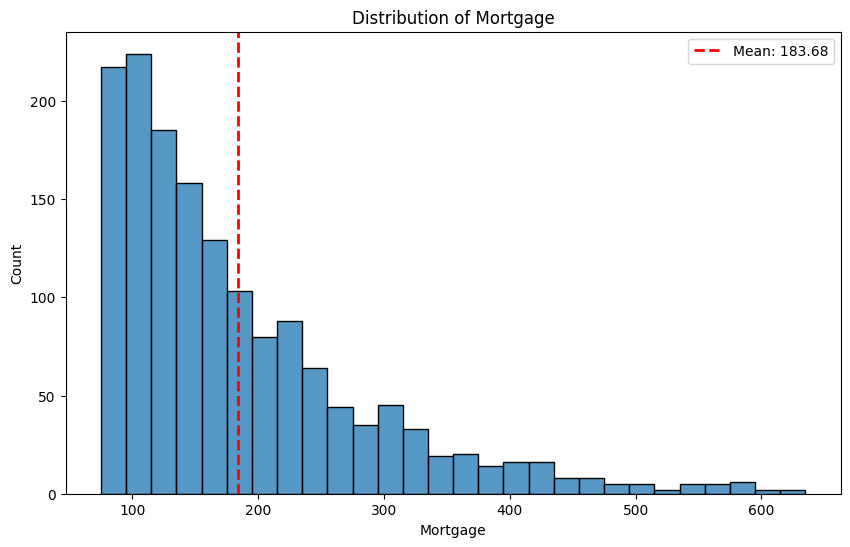

In [ ]:
# plotting histogram for customers having mortgage(mortgage > 0)
plt.figure(figsize=(10,6))
mortgage_mean = mortgage_cust_num["Mortgage"].mean()
print(f"Mean of Mortgage: {mortgage_mean}")
sns.histplot(data=mortgage_cust_num, x="Mortgage")
# add the vertical line at the mean
plt.axvline(mortgage_mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {mortgage_mean:.2f}")
plt.title(f"Distribution of Mortgage")
plt.xlabel("Mortgage")
plt.legend()
plt.show()

**Observations:**

*The mortgage distibution of the customers having mortgage is heavily right skewed with a min value of approximately 99,000 in dollars to max value of approximately 635,000 in dollars and mean value is approximately 184,000 in dollars.*

***Grouping features Education, Personal_Loan, Securities_Account, CD_Account, Online, CreditCard for univariate analysis values of which are Categorical in nature***

Distribution of Education:
 Undergrad  Professional  Graduate
     41.92         30.02     28.06
Distribution of Personal_Loan:
  No  Yes
90.4  9.6
Distribution of Securities_Account:
   No   Yes
89.56 10.44
Distribution of CD_Account:
   No  Yes
93.96 6.04
Distribution of Online:
  Yes    No
59.68 40.32
Distribution of CreditCard:
  No  Yes
70.6 29.4


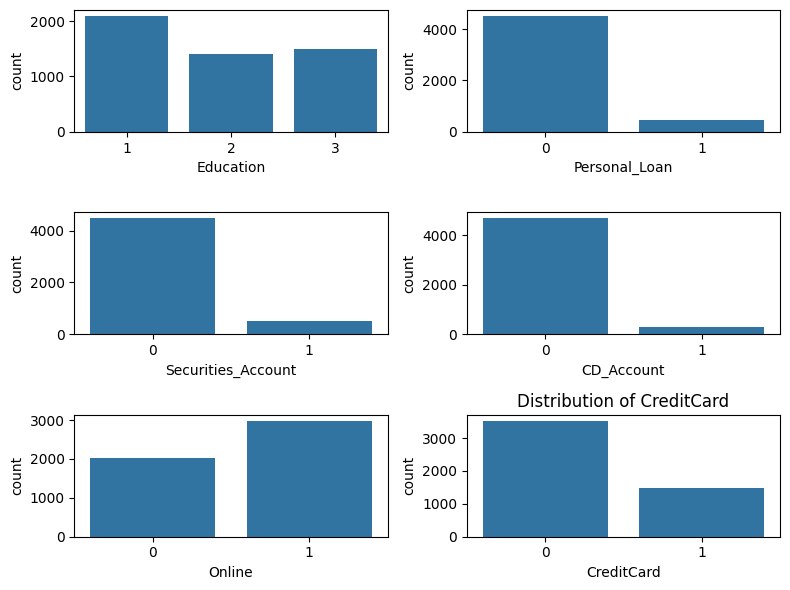

In [ ]:
plt.figure(figsize=(8,6))
cat_features = ["Education", "Personal_Loan", "Securities_Account", "CD_Account", "Online", "CreditCard"]

# creating mapping dictionary to easily interpret 0's and 1's in dataset
labels_map = {
    "Education": {1: "Undergrad", 2: "Graduate", 3: "Professional"},
    "Personal_Loan": {0: "No", 1: "Yes"},
    "Securities_Account": {0: "No", 1: "Yes"},
    "CD_Account": {0: "No", 1: "Yes"},
    "Online": {0: "No", 1: "Yes"},
    "CreditCard": {0: "No", 1: "Yes"}
}

for i, feature in enumerate(cat_features):
  plt.subplot(3, 2, i+1)
  # checking the distribution of the categories in cat_features
  dist = (100 * loan_customers[feature].value_counts(normalize=True)).to_frame().T
  dist.columns = dist.columns.map(labels_map[feature])
  print(f"Distribution of {feature}:")
  print(dist.to_string(index=False))
  #plotting countplot for cat_features
  sns.countplot(data=loan_customers, x=feature)
plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.tight_layout()
plt.show()

**Plotting countplot for County column (added after translating the ZIPCode column)**

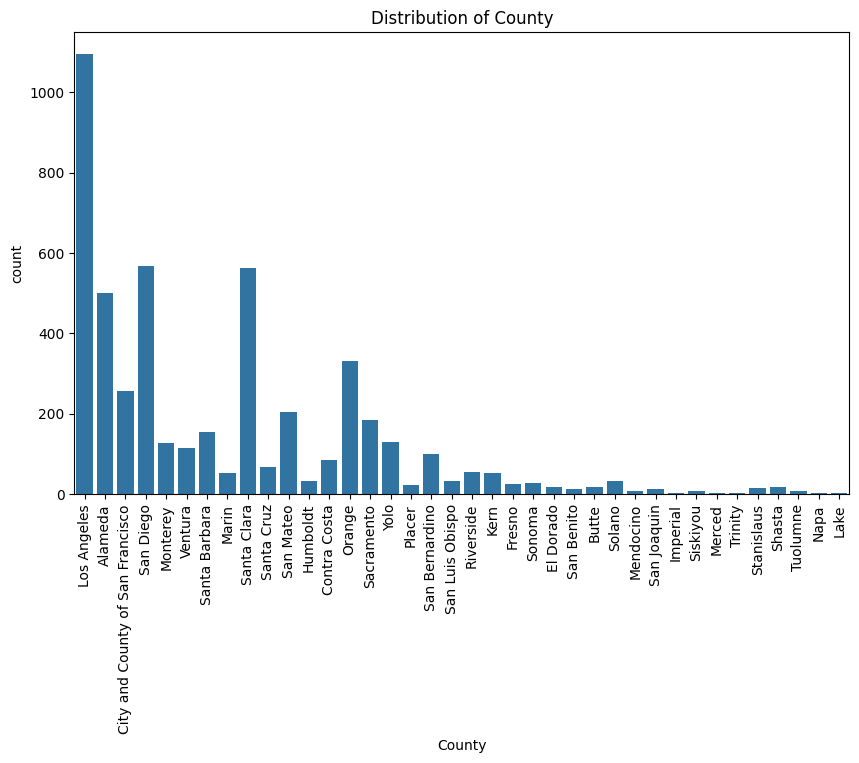

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=loan_customers, x="County")
plt.title("Distribution of County")
plt.xticks(rotation=90)
plt.show()


**Observations:**

* *41.9% of customers are 1(Undergrad per mapping)*,
  *28.1% of customers are 2(Graduate per mapping)*,
  *30.0% of customers are 3(Advanced/Professional per mapping).*

* *90.4% of customers did not accept(value 0 in Dataset) loan in last campaign*,
  *9.6% of customers accepted(value 1 in Dataset) loan in last campaign.*

* *89.56% of customers do not have(value 0 in Dataset) Securities Account*,
  *10.44% of customers have(value 1 in Dataset) Securities Account.*

* *94% of customers do not have(value 0 in Dataset) a CD_Account with the bank*,
  *6% of customers have(value 1 in Dataset) a CD_Account with the bank.*

* *59.7% of customers use(value 1 in Dataset) the online banking services*,
  *40.3% of customers do not use(value 0 in Dataset) the online banking services.*

* *70.6% of customers do not use(value 0 in Dataset) credit card issued by any other bank excluding AllLife Bank*,
  *29.4% of customers use(value 1 in Dataset) credit card issued by any other bank excluding AllLife Bank.*

* *Max population is from Los Angeles followed by next in numbers are San Diego and Santa Clara counties.*



**Multivariate Analysis**

**Plotting pair plot for Numerical features ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage"]**

<Figure size 1500x1500 with 0 Axes>

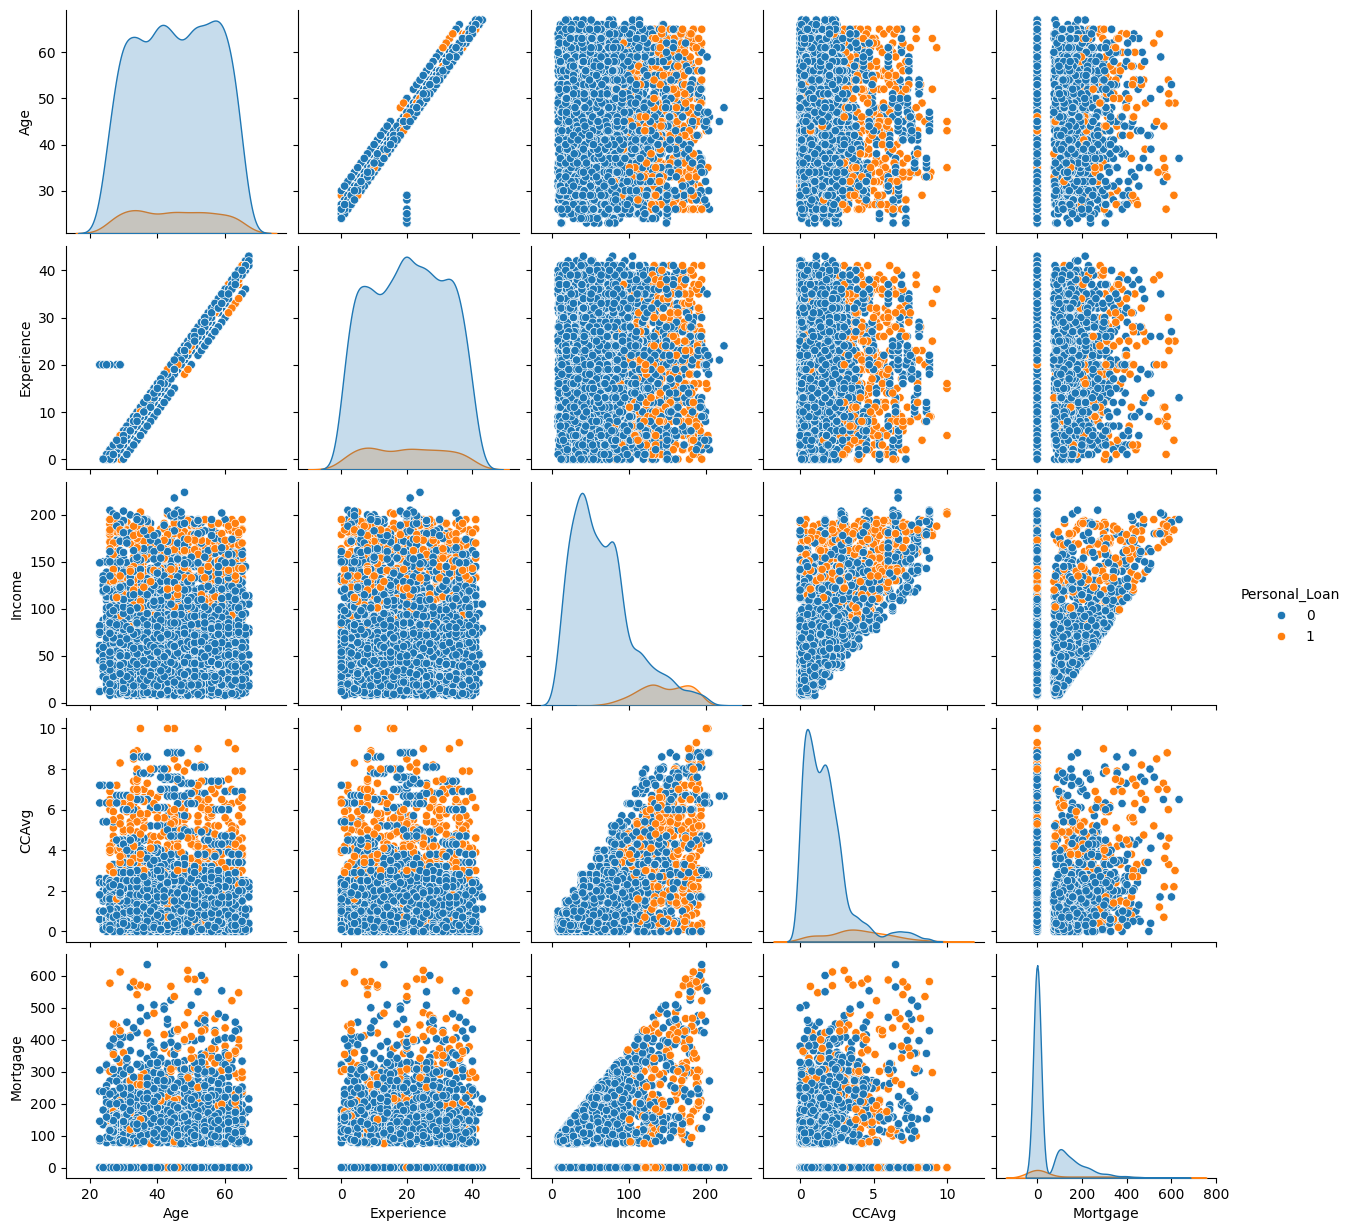

In [ ]:
# Scatter plot matrix
plt.figure(figsize=(15, 15))
columns_to_plot = ["Age", "Experience", "Income", "CCAvg", "Mortgage", "Personal_Loan"]
sns.pairplot(loan_customers[columns_to_plot], hue="Personal_Loan", diag_kind="kde");

**Observations:**

* *The orange spots present the customers who accepted a personal_loan and the blue spots show the ones who did not.*

* *Customers who accepted the personal loan tend to have significantly higher Income and CCAvg (average spending on credit cards) compared to those who did not. The diagonal separation suggests that high income combined with high credit card spending is a strong indicator for personal loan acceptance.*

* *High concentraion of customers who accepted a personal loan are observed at higher Income level starting at approximately 100,000 and above.*

* *Age and Experience don't show a clear linear separation with Personal_Loan in the scatter plots, indicating a less direct linear relationship, though they might still contribute to the model when combined with other attributes.*

* *Higher mortgage values might also correlate with higher loan acceptance, but Income and CCAvg appear to be more dominant.*

#### *To further understand the linear relationships, examining the correlation matrix to find correlation of all the features excluding "ID" and "Zipcode".*


***Calculating Correlation matrix of all features excluding "ID"***

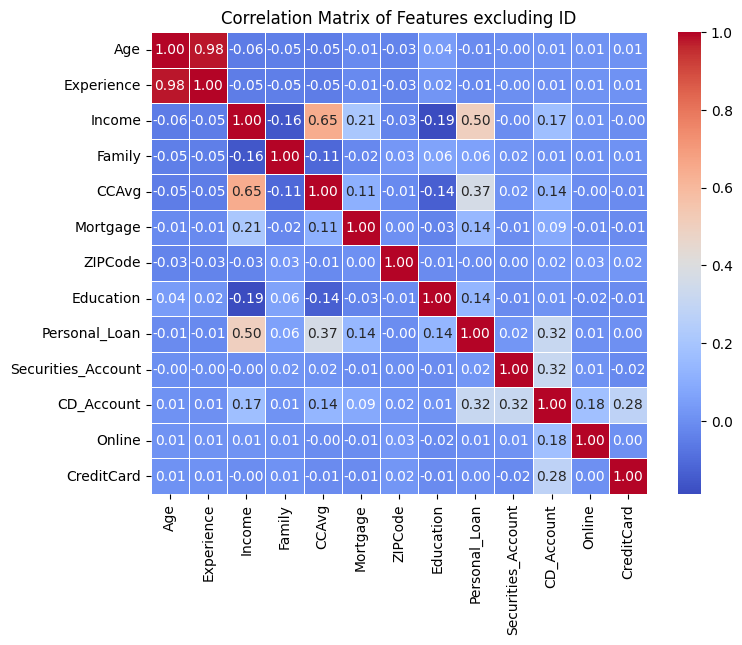

In [ ]:
# calculating the correlation matrix for processed data (excluding ID and ZIPCode)
corr_features = ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage", "ZIPCode", "Education", "Personal_Loan", "Securities_Account", "CD_Account", "Online", "CreditCard"]
correlation_matrix_processed = loan_customers[corr_features].corr()

# Plotting the heatmap for processed data
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_processed, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Correlation Matrix of Features excluding ID")
plt.show()

**Observations:**

***Correlations with `Personal_Loan:***

* *Income (correlation with Personal_Loan is 0.50): This is the strongest positive correlation with Personal_Loan. It indicates that customers with higher incomes are likely to accept a personal loan. This aligns with the visual observations from the pair plots, where higher income customers approx 100,000 in dollars and above showed a clear probability for taking loans.*

* *CCAvg (correlation with Personal_Loan is 0.37): The average monthly credit card spending also shows a strong positive correlation with Personal_Loan which coveys that customers who spend more on their credit cards are more inclined to take out a personal loan.*

* *CD_Account (correlation with Personal_Loan is 0.32): Customers who have a Certificate of Deposit (CDAccount) with the bank are moderately more likely to accept a personal loan. This might indicate a customer segment that is more engaged with the bank's financial products and potentially has more assets.*

* *Education (correlation with Personal_Loan is 0.14): There's a positive, but weaker correlation with Education.*

* **As seen in correlation matrix, ZIPCode has no correlation to Personal_Loan and hence can be dropped from the Data set.**

* *Securities_Account (correlation with Personal_Loan is 0.02): The correlation here is very weak almost negligible. Having a securities account does not appear to be a significant predictor of personal loan acceptance.*

* *Family (correlation with Personal_Loan is -0.01): The correlation is negligible and slightly negative. Family size doesn't seem to play a role in loan acceptance. Could drop this column in further Model building process.*

* *Age (correlation with Personal_Loan is -0.01) and Experience (correlation with Personal_Loan is -0.01): Both Age and Experience show practically no linear correlation with Personal_Loan. While they might interact with other features their direct impact on loan acceptance is minimal.*

* *Online (correlation with Personal_Loan is 0.01): Using online banking facilities has a very weak, almost zero, correlation with Personal_Loan.*

* *CreditCard (correlation with Personal_Loan is 0.00): Owning a credit card from another bank shows no correlation with personal loan acceptance from AllLife Bank.*

* *Mortgage (correlation with Personal_Loan is 0.14): There may be slight correlation, customers who have higher mortgage payments may be tend to accept personal loan.*

* *Age and Experience (correlation is 0.98): Age and Experience are highly positively correlated. This is very common, as professional experience generally increases with age.*
.
* *Income and CCAvg (correlation is 0.65): There is a strong positive correlation between Income and CCAvg implying that customers with higher incomes tend to have higher credit card spending. This combined importance as predictors for Personal_Loan should be considered.*

* *Income and Education (correlation is -0.19): There is negative correlation, no significance observed.*

* *Age/Experience and Mortgage (correlation is -0.01): There is negative correlation, no significance observed.*

* *Securities_Account and CD_Account (correlation is 0.32): Customers who have a securities account are moderately more likely to also have a CD account.*

**Conclusions from Correlation Analysis:**

1. *Top Predictors: Income and CCAvg are the most influential features for predicting Personal_Loan showing strong positive correlations.*
2. *Secondary Predictors: CD_Account and Education also contribute positively to some extent.*
3. *Less Relevant Features: Age, Experience, Family, Mortgage, Online, Securities_Account, and CreditCard have very weak or negligible linear correlation with the Personal_Loan.*
4. *Multicollinearity: The high correlation between `Age` and `Experience` is seen.*

**Dropping "ZIPCode", "County", "State" column as it serves no importance to target variable Personal_Loan**

In [ ]:
loan_customers.drop("ZIPCode", axis=1, inplace=True)
loan_customers.drop("County", axis=1, inplace=True)
loan_customers.drop("State", axis=1, inplace=True)

***Visualizing the distribution of numerical features for customers who accepted a personal loan versus those who did not, using boxplots***

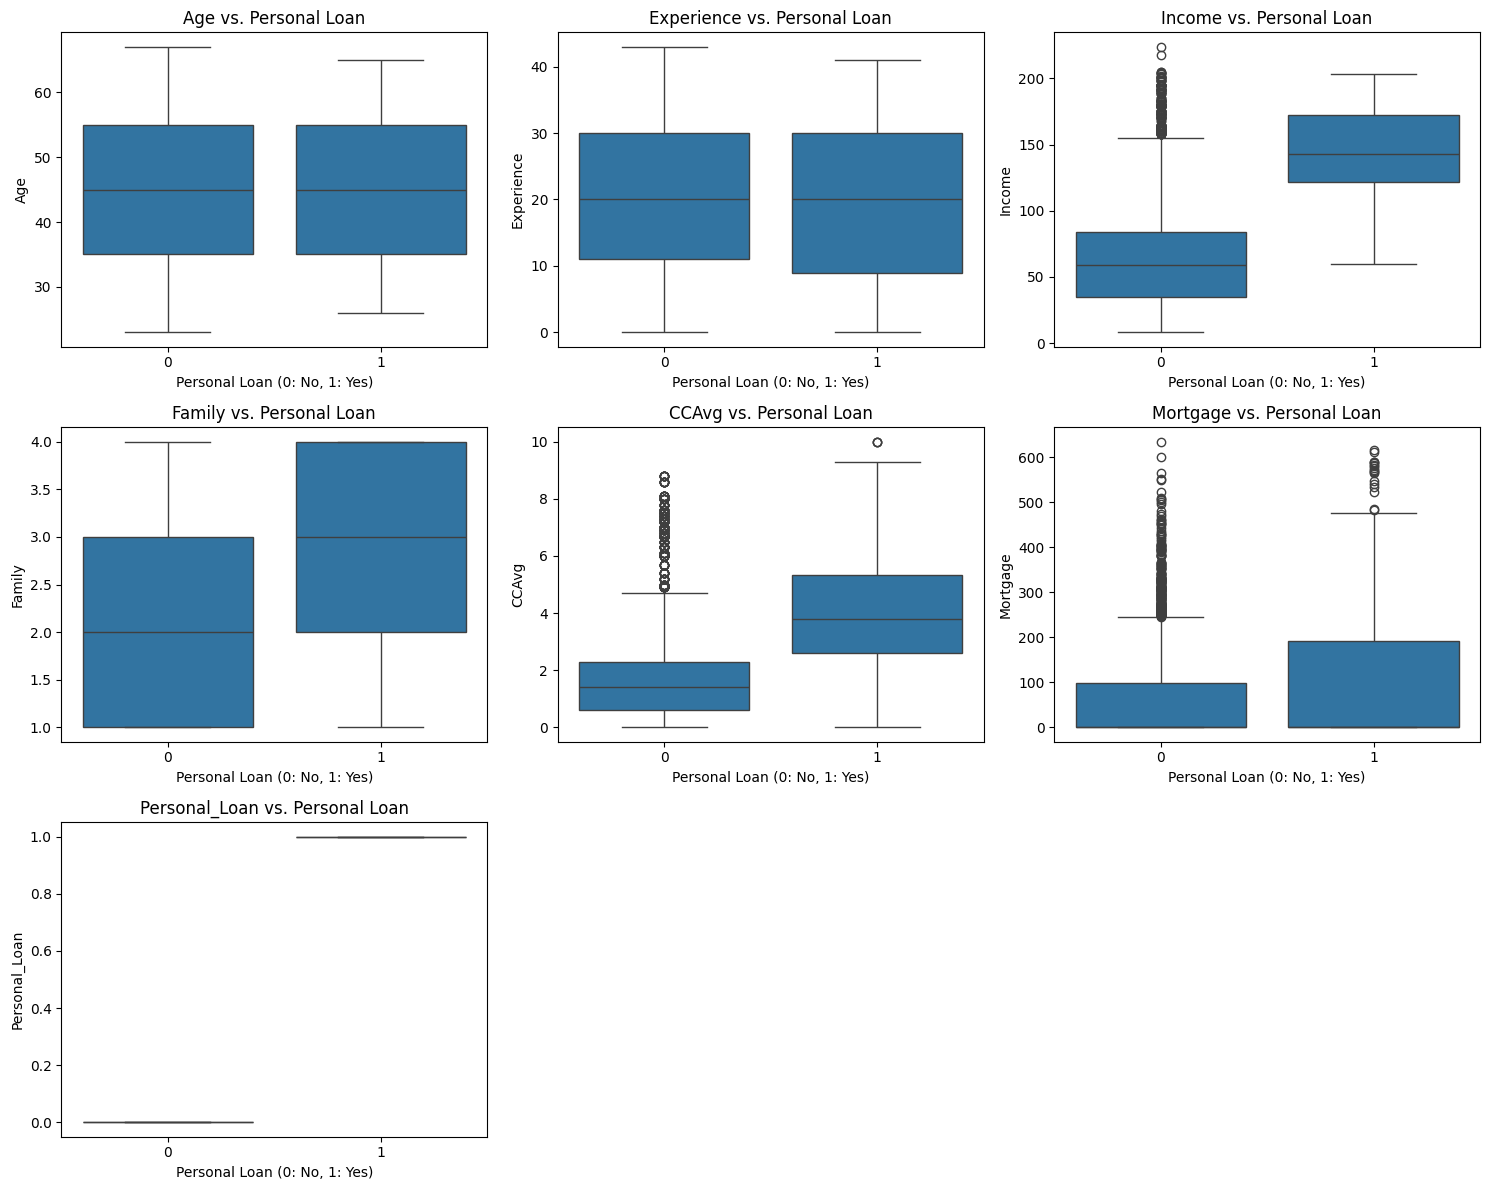

In [ ]:
numerical_features = ["Age", "Experience", "Income", "Family", "CCAvg", "Mortgage", "Personal_Loan"]
loan_customers_processed = loan_customers[numerical_features]
plt.figure(figsize=(15, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=loan_customers_processed, x="Personal_Loan", y=feature)
    plt.title(f"{feature} vs. Personal Loan")
    plt.xlabel("Personal Loan (0: No, 1: Yes)")
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

**Observations:**

* *Income: There is a clear distinction in "Income" distribution. Customers who accepted a personal loan have significantly higher median income and a higher overall income range compared to those who did not. This confirms "Income" as a strong predictor.*

* *CCAvg: Similar to "Income", "CCAvg" shows a much higher median and range for customers who accepted a personal loan. This further strengthens "CCAvg" as a key differentiator.*

* *Age & Experience: The distributions for "Age" and "Experience" are quite similar with 5 number statistics almost the same for both "Personal_Loan" groups.This weak linear correlation observed earlier and now with 5 number stats indicate that they are not the predictors for the target variable.*

* *Family: The "Family" size distributions are also very similar for both groups indicating it might not be a strong predictor.*

* *Mortgage: The median "Mortgage" value is 0 for both groups, as a large portion of customers have no mortgage. However for those with mortgages, customers who accepted a loan appear to have slightly higher mortgage values, though the difference is not as significant as with "Income" or "CCAvg".*

***Creating crosstabs and countplots to visualize Categorical features against target feature Personal_Loan***


Crosstab for Education vs. Personal_Loan:
Personal_Loan      0      1
Education                  
1              95.56   4.44
2              87.03  12.97
3              86.34  13.66


<Figure size 700x500 with 0 Axes>

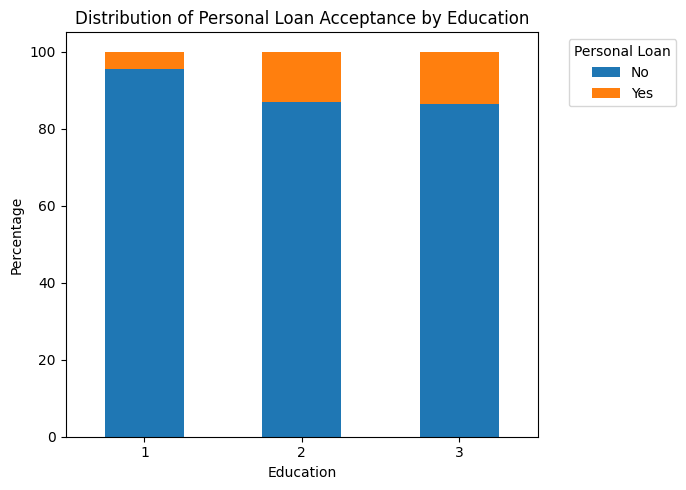


Crosstab for Securities_Account vs. Personal_Loan:
Personal_Loan           0      1
Securities_Account              
0                   90.62   9.38
1                   88.51  11.49


<Figure size 700x500 with 0 Axes>

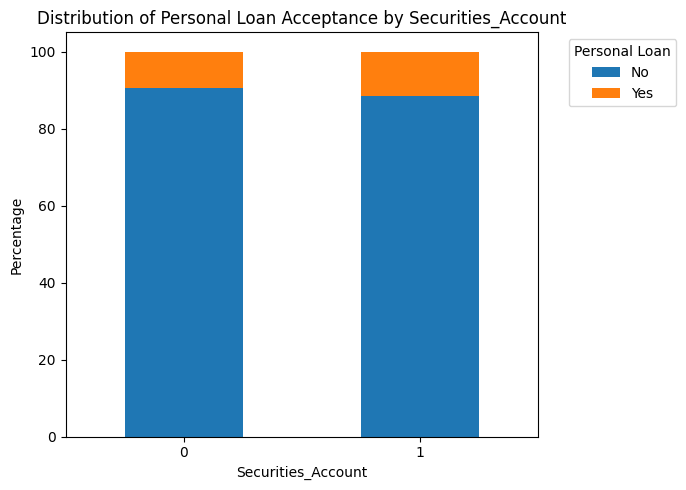


Crosstab for CD_Account vs. Personal_Loan:
Personal_Loan      0      1
CD_Account                 
0              92.76   7.24
1              53.64  46.36


<Figure size 700x500 with 0 Axes>

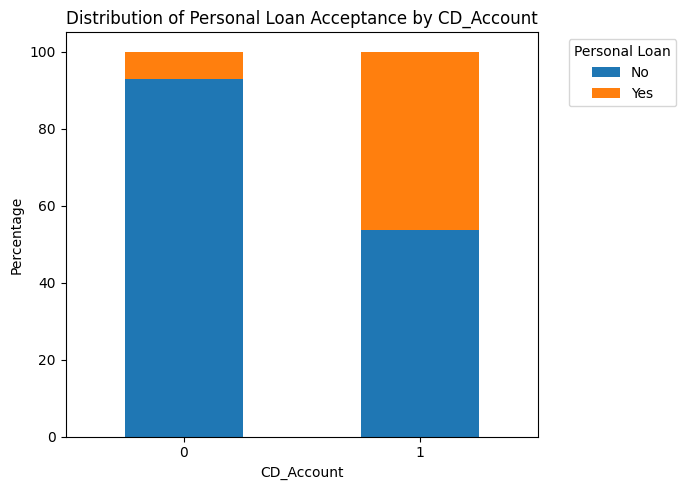


Crosstab for Online vs. Personal_Loan:
Personal_Loan      0     1
Online                    
0              90.62  9.38
1              90.25  9.75


<Figure size 700x500 with 0 Axes>

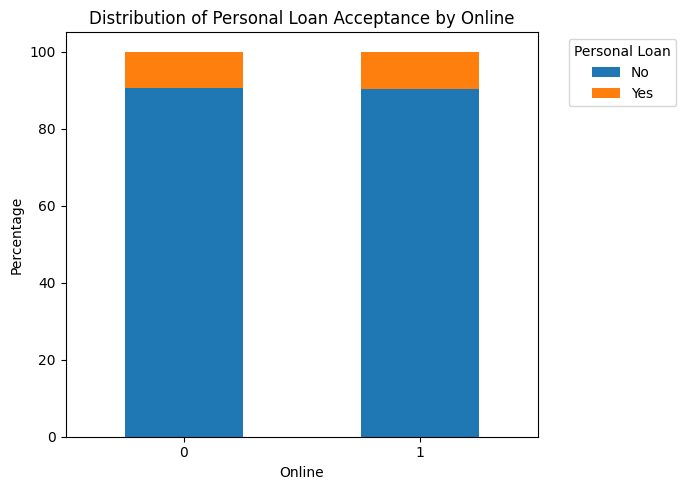


Crosstab for CreditCard vs. Personal_Loan:
Personal_Loan      0     1
CreditCard                
0              90.45  9.55
1              90.27  9.73


<Figure size 700x500 with 0 Axes>

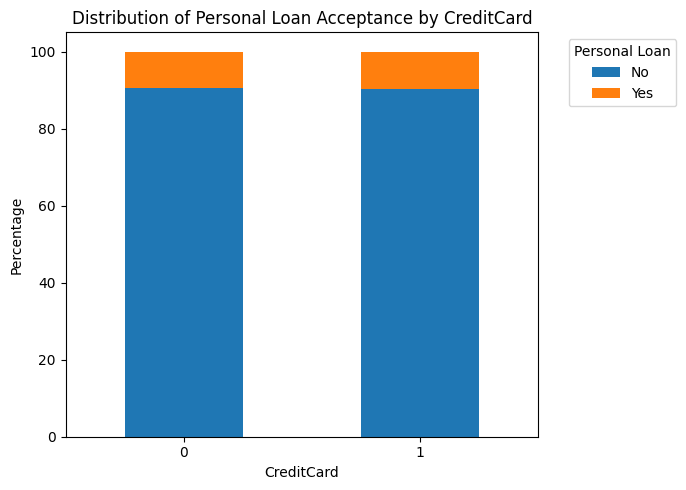

In [ ]:
categorical_features = ["Education", "Securities_Account", "CD_Account", "Online", "CreditCard"]

for feature in categorical_features:
    print(f"\nCrosstab for {feature} vs. Personal_Loan:")
    crosstab = pd.crosstab(loan_customers[feature], loan_customers["Personal_Loan"], normalize="index") * 100
    print(crosstab.round(2))

    plt.figure(figsize=(7, 5))
    crosstab.plot(kind='bar', stacked=True, figsize=(7, 5))
    plt.title(f"Distribution of Personal Loan Acceptance by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Percentage")
    plt.legend(title="Personal Loan", labels=["No", "Yes"], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

**Observations:**

* **Education:** *Customers with higher education levels (Graduate and Advanced/Professional, which are categories 2 and 3) have a significantly higher percentage of personal loan acceptance compared to undergraduates (category 1).*

* **CD_Account:** *Customers who have a Certificate of Deposit (CD) account with the bank (category 1) are much more likely to accept a personal loan than those who do not (category 0)*

* **Securities_Account:** *There's a slight increase in personal loan acceptance among customers who have a securities account (category 1) compared to those who don't (category 0) but the difference is not as significant as with CD accounts*

* **Online:** *The proportion of customers accepting a personal loan is very similar for those who use online banking (category 1) and those who don't (category 0). This suggests that online banking usage is not a strong predictor of personal loan acceptance.*

* **CreditCard:** *Owning a credit card from another bank (category 1) does not show a significant difference in the likelihood of accepting a personal loan compared to not owning one (category 0).*

## Model Building

### Model Evaluation Criterion

### *Summary of the steps planning to execute in Model Evaluation*:

*The goal is to identify potential customers who have a higher probability of purchasing the loan by correctly identifying customers who will accept the loan (positive class which is Personal_Loan = 1).*

*For the positive class focussing on below metrics:*

* **Confusion Matrix**: *To understand the types of errors the model is making (True Positives, False Positives, True Negatives, False Negatives).*

* **Accuracy**: *The proportion of correctly classified instances.*

* **Precision (for class 1)**: *Of all the instances predicted as positive, how many were actually positive? High precision means fewer false positives.*

* **Recall (for class 1)**: *Of all the actual positive instances, how many were correctly identified as positive? High recall means fewer false negatives which ensures we capture potential loan buying customers.*

* **F1-Score (for class 1)**: *The harmonic mean of precision and recall. It provides a single metric that balances both precision and recall, which is particularly useful when both false positives and false negatives are important to consider.*

*Since the bank wants to expand its customer base and effectively target customers, **recall_score** and **f1_score** for the positive class (customers who will buy the loan) is a important metric to maximize as it directly reflects the ability to identify potential loan buyers.*

### *Baseline Decision Tree Model Building*

*Will start now by building a Decision Tree Classifier with default parameters as baseline model.*

### Data Preprocessing for Model Building

*Before building the model, we need to prepare our data:*

1. **Assign Features and Target**: *Defining independent variables (X) and dependent variable (y) which is "Personal_Loan".*

2. **Split Data**: *The data will be split into training and testing sets to evaluate the model's performance on unseen data. I am using stratify argument to maintain the same proportion of the target variable in both train and test sets.*

In [ ]:
# Defining features X and target y
X = loan_customers.drop("Personal_Loan", axis=1)
y = loan_customers["Personal_Loan"]

# Splitting the data into training and testing sets
# Using stratify to ensure an even distribution of "Personal_Loan" in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of Personal_Loan in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of Personal_Loan in test set:")
print(y_test.value_counts(normalize=True))

X_train shape: (3500, 12)
X_test shape: (1500, 12)
y_train shape: (3500,)
y_test shape: (1500,)

Distribution of Personal_Loan in training set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64

Distribution of Personal_Loan in test set:
Personal_Loan
0    0.904
1    0.096
Name: proportion, dtype: float64


**Comments:**

* *Dropped columns in Data set which are not contributing to the target variable "Personal_Loan".*

* *Split the Data set in to training and test sets.*

* *Estimated distribution of Personal_Loan in training and test sets and it can seen that using straitfy maintained same proportion of target varaible "Personal_Loan" in both training and test sets.*

In [ ]:
# Initialize the Decision Tree Classifier with a random state for reproducibility
dtree1_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dtree1_model.fit(X_train, y_train)

print("Baseline Decision Tree model trained successfully.")

Baseline Decision Tree model trained successfully.


**Comments**

*Created instance of Decision tree and fitted the model with training set.*

### Model Evaluation

 *Creating a function that takes the actual and predicted labels to calculate and print the confusion_matrix, accuracy_score, precision_score, recall_score, and f1_score*

In [ ]:
# defining a function to compute different metrics to check performance of a classification model
# model: classifier, predictors: independent variables, target: dependent variable
def model_performance_classification(model, predictors, target):

    # predicting using the independent variables
    pred = model.predict(predictors)
    # to compute accuracy_score
    accuracy = accuracy_score(target, pred)
    # to compute Recall_score
    recall = recall_score(target, pred)
    # to compute Precision_score
    precision = precision_score(target, pred)
    # to compute f1-score
    f1 = f1_score(target, pred)

    # creating a dataframe of above calculated metrics
    df_perf = pd.DataFrame(
        {"Accuracy": accuracy, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

**Comments:**

*Predicting the Decision tree model using independent varaibles(predictors), calculating performance metrics and creating DataFrame for calculated metrics.*

In [ ]:
# defining a function to plot confusion_matrix with percentages
# model: classifier, predictors: independent variables, target: dependent variable
def plot_confusion_matrix(model, predictors, target):

    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictors)

    # Compute the confusion matrix comparing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    # Create numpy array of labels for each cell in the confusion matrix with both count and percentage and reshaping as matrix
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))

    # Plot the confusion matrix as a heatmap with the labels
    sns.heatmap(cm, annot=labels, fmt="")

    # Add a label to the y-axis
    plt.ylabel("True label")

    # Add a label to the x-axis
    plt.xlabel("Predicted label")

**Comments:**

* *Defining a function to plot confusion_matrix with percentages.*

* *Predicting the target values using the provided model and predictors
Compute the confusion matrix comparing the actual target values with the predicted values.*

* *Creating numpy array of labels for each cell in the confusion matrix with both count and percentage and reshaping as matrix.*

* *Plot the confusion matrix as a heatmap with the labels.*

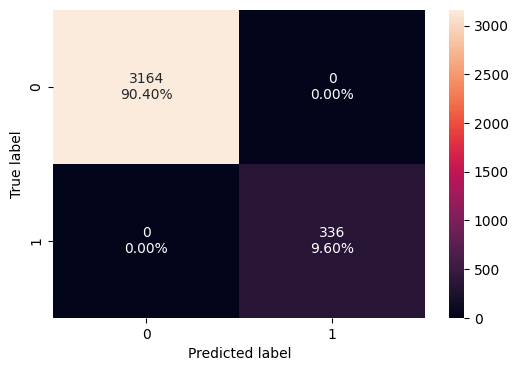

In [ ]:
# Plotting confusion matrix with train set
plot_confusion_matrix(dtree1_model, X_train, y_train)

**Observations:**

*Confusion_matrix for train data indicates that the baseline Decision Tree model has perfectly learned the training data correctly classifying all positive and negative instances.*

In [ ]:
# Calculating model performance metrics on train set
dtree1_train_perf = model_performance_classification(
    dtree1_model, X_train, y_train
)
dtree1_train_perf

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


**Observations:**

*The model achieved perfect scores on the training data: accuracy_score = 1.0, recall_score = 1.0, precision_score = 1.0, and f1_Score = 1.0.*

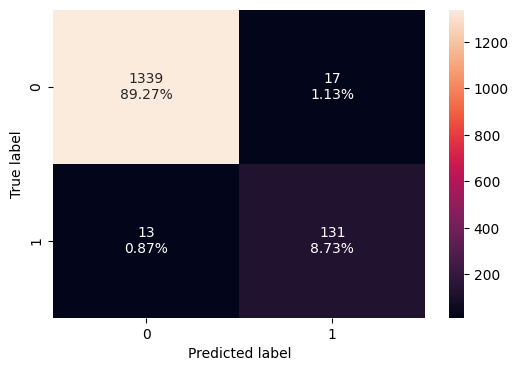

In [ ]:
# Plotting confusion matrix with test set
plot_confusion_matrix(dtree1_model, X_test, y_test)

In [ ]:
# Calculating model performance metrics on test set
dtree1_test_perf = model_performance_classification(
    dtree1_model, X_test, y_test
)
dtree1_test_perf

,Accuracy,Recall,Precision,F1
0,0.98,0.909722,0.885135,0.89726


**Observations:**

* *The model achieved an accuracy of approximately 98.07% on the test set.*

* *Recall (for Personal_Loan = 1): The recall score for the positive class (customers who accepted a personal loan) is approximately 90.97%. This means the model correctly identified about 91% of all actual loan acceptors.*

* *Precision (for Personal_Loan = 1): The precision score for the positive class is approximately 89.12%. This means that when the model predicted a customer would accept a loan it was correct about 89% of the time.*

* *F1-Score (for Personal_Loan = 1): The f1_score, which is a harmonic mean of precision and recall is approximately 90.03%.*

**Comparison with Training Data:**

* *Comparing these test set results to the perfect scores (1.0 for all metrics) obtained on the training set I see a noticeable drop in performance. This indicates that the baseline Decision Tree model has overfit the training data.*

* *Despite the overfitting, the recall of nearly 91% for the positive class is still good which implies that model is effective at identifying most potential loan customers which is a key objective for the bank.*

**Visualizing the Decision Tree**

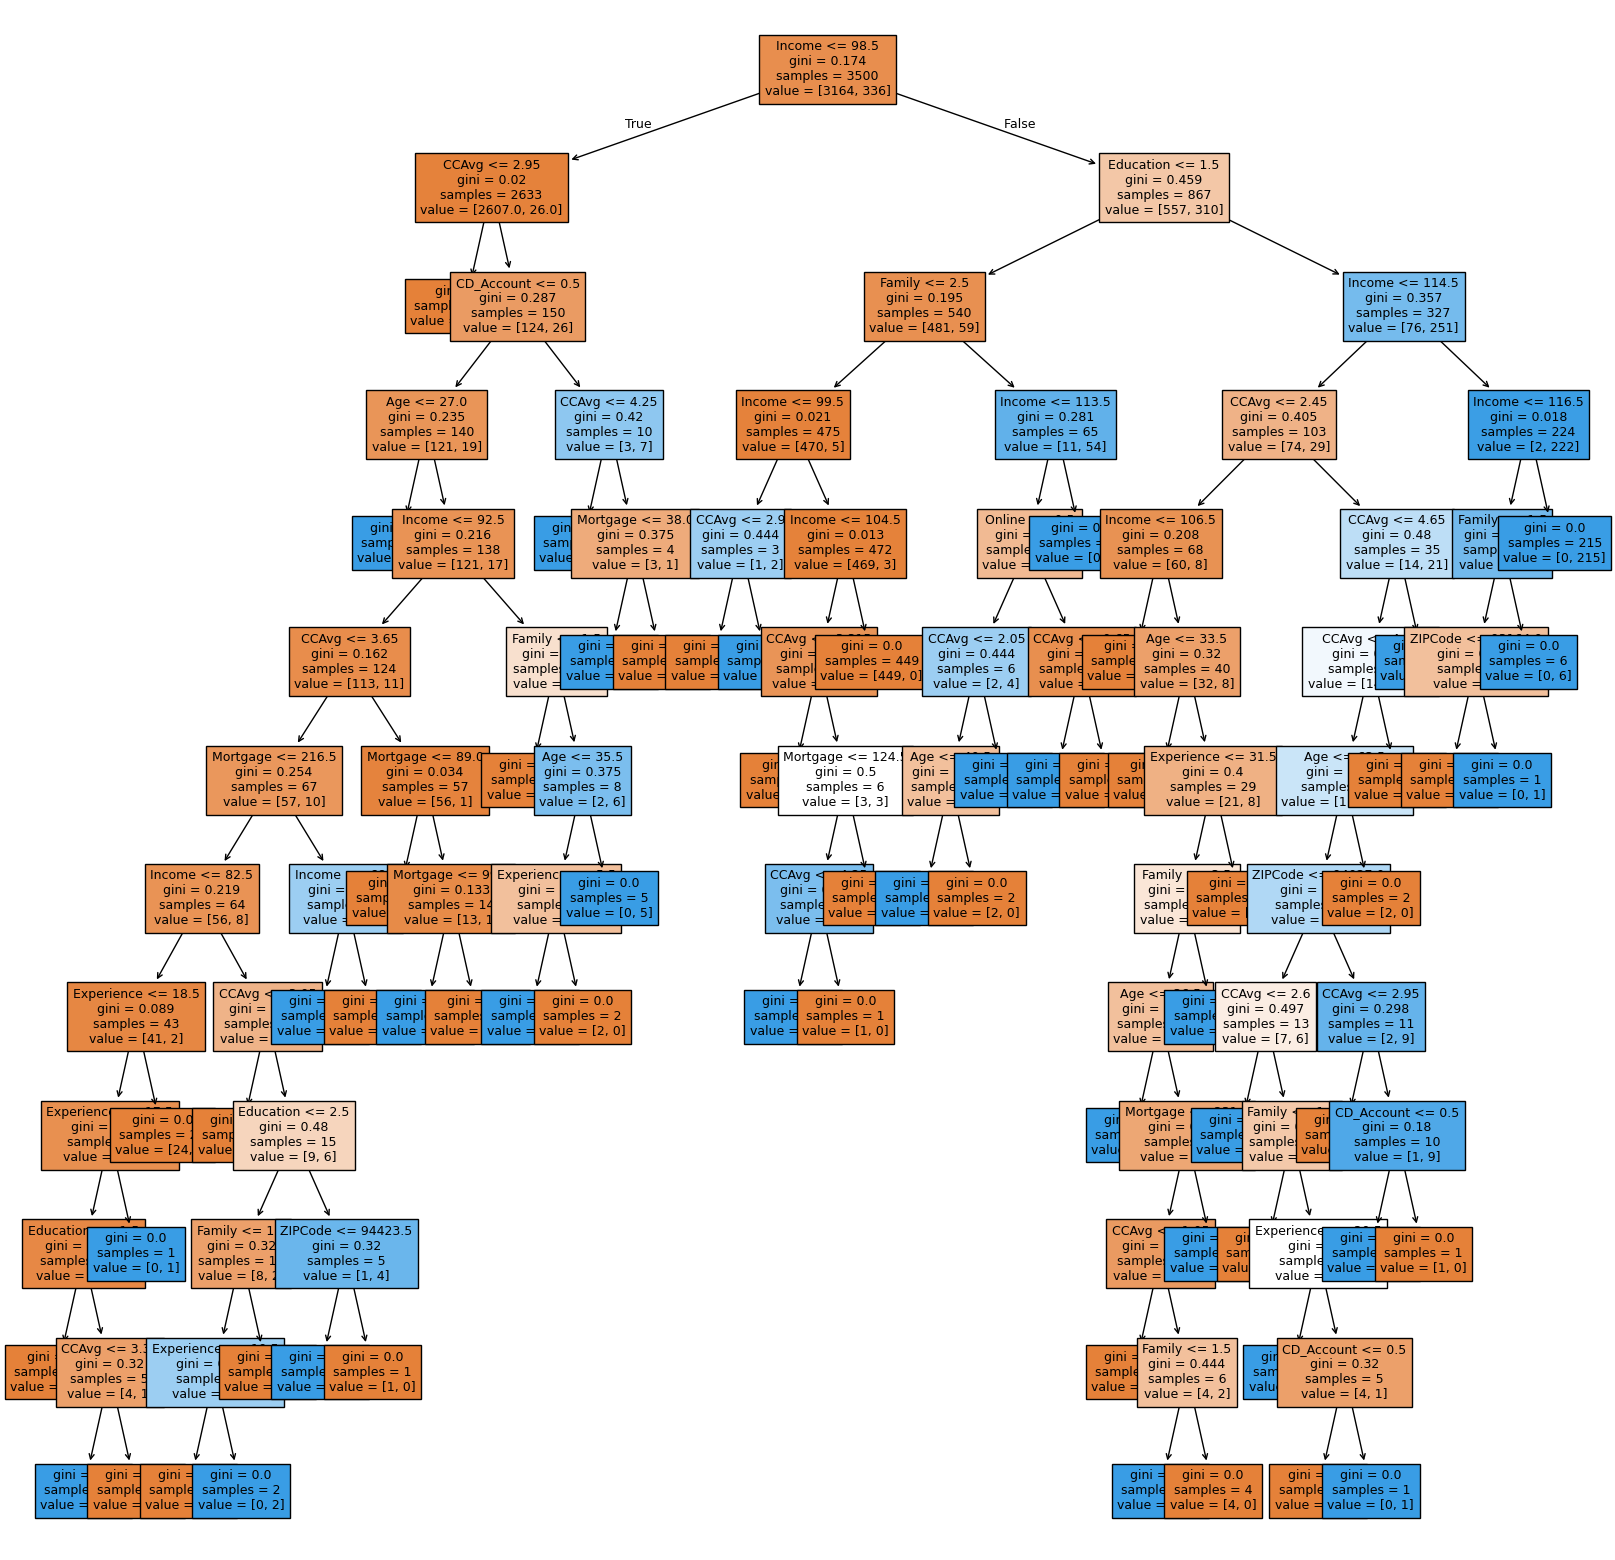

In [ ]:
# Visualizing the Decision Tree
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree1_model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)

# add arrows to the decision tree splits
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)

plt.show()


**Observations:**

* *The generated plot displays the entire structure of the Decision Tree model that was trained. Each node in the tree represents a decision rule based on a feature, and the leaves represent the final classification (0 for no personal loan, 1 for yes).*

* *The tree is very deep and complex*

* *The extensive branching and depth of the tree are clear indicators of overfitting which often leads to poor generalization on unseen data.*

* *Due to its depth and the large number of nodes this tree is difficult to interpret manually and it is hard to find which features are most impactful or how they interact at different levels of the tree.*

* *While challenging to read, still could observe that features like Income and CCAvg appear frequently near the top of the tree indicating their importance in the initial splits which aligns with earlier correlation analysis.*

**Printing a text report showing the rules of a decision tree**

In [ ]:
# printing a text report showing the rules of a decision tree
print(
    tree.export_text(
        dtree1_model,
        feature_names=feature_names,
        show_weights=True
    )
)

|--- Income <= 98.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [2483.00, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- Age <= 27.00
|   |   |   |   |--- weights: [0.00, 2.00] class: 1
|   |   |   |--- Age >  27.00
|   |   |   |   |--- Income <= 92.50
|   |   |   |   |   |--- CCAvg <= 3.65
|   |   |   |   |   |   |--- Mortgage <= 216.50
|   |   |   |   |   |   |   |--- Income <= 82.50
|   |   |   |   |   |   |   |   |--- Experience <= 18.50
|   |   |   |   |   |   |   |   |   |--- Experience <= 17.50
|   |   |   |   |   |   |   |   |   |   |--- Education <= 1.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [13.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |   |--- Education >  1.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |--- Experience >  17.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   | 

**Comments:**

*This is just a text report showing the rules of a decision tree.*

## Model Performance Improvement

### Decision Tree Pre-pruning

*To prevent overfitting and improve the generalization of the Decision Tree model built, will perform pre-pruning. This involves setting constraints on the tree's growth during training. Setting key hyperparameters for pre-pruning below.*

* *max_depth: The maximum depth of the tree.*
* *min_samples_leaf: The minimum number of samples required to be at a leaf node.*
* *min_samples_split_values: The minimum sample values in the split.*



In [ ]:
# defining the hyperparameters of the Decision tree
max_depth_values = np.arange(2, 11, 2)
max_leaf_nodes_values = np.arange(10, 51, 10)
min_samples_split_values = np.arange(10, 51, 10)

# initializing variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')

# using for loop to iterate over all hyperparameters
for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            # initializing the tree with the current set of hyperparameters
            estimator = DecisionTreeClassifier(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )

            # fitting the model to the training data
            estimator.fit(X_train, y_train)

            # predictions on the training and test sets
            y_train_pred = estimator.predict(X_train)
            y_test_pred = estimator.predict(X_test)

            # calculating f1 scores for training and test sets
            train_f1_score = f1_score(y_train, y_train_pred)
            test_f1_score = f1_score(y_test, y_test_pred)

            # calculating the absolute difference between training and test f1 scores
            score_diff = abs(train_f1_score - test_f1_score)

            # best estimator and best score
            if score_diff < best_score_diff:
                best_score_diff = score_diff
                best_estimator = estimator

**Comments:**

*To find the best model and best score of the tree, defined hyperparameters for the tree and using those parameters and estimated the model, fitted and predicted the model for train and test data. Calculated f1_score for both training and test sets and calculated absolute of difference between f1 score for training set and f1 score for test set. Then determined the best model and best score for the model.*



In [ ]:
# creating an instance of the best model
dtree2 = best_estimator

# fitting the best model to the training data
dtree2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(4), max_leaf_nodes=np.int64(20),
                       min_samples_split=np.int64(10), random_state=42)

**Comments:**

*Creating an instance of the best model and fitting it on training data.*

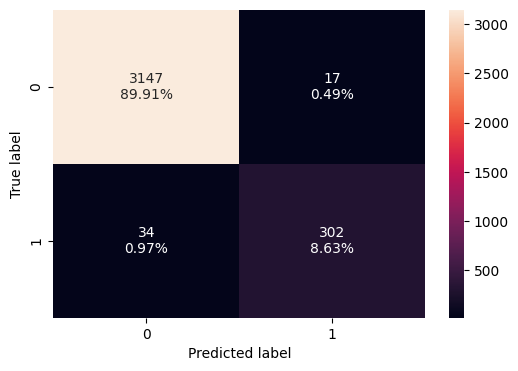

In [ ]:
# Plotting confusion_matrix for best model on training data
plot_confusion_matrix(dtree2, X_train, y_train)

In [ ]:
# Calculating Performance metrics for best model on training data
dtree2_train_perf = model_performance_classification(
    dtree2, X_train, y_train
)
dtree2_train_perf

,Accuracy,Recall,Precision,F1
0,0.985429,0.89881,0.946708,0.922137


**Observations:**

* *The pruned Decision Tree model shows strong performance on the training data, achieving an accuracy of approximately 98.54%.*

* *The model identified about 89.88% of all actual loan acceptors in the training set.*

* *When the model predicted a customer would accept a loan it was correct about 94.67% of the time on the training set.*

* *The F1-score balancing precision and recall is approximately 92.21%.*

* *Compared to the baseline model's perfect scores on the training data, this pruned model shows slightly reduced, but still very high performance. This suggests that model is now less overfit and likely to generalize better on test data.*

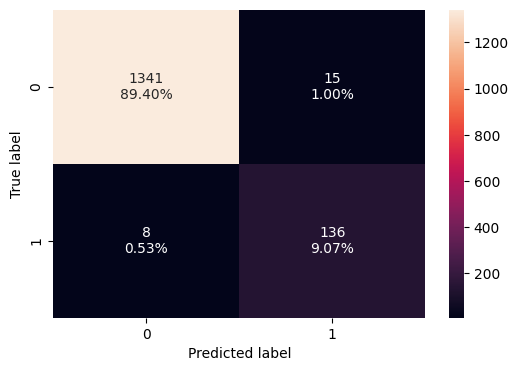

In [ ]:
# Plotting confusion_matrix for best model on test data
plot_confusion_matrix(dtree2, X_test, y_test)

In [ ]:
# Calculating Performance metrics for best model on test data
dtree2_test_perf = model_performance_classification(
    dtree2, X_test, y_test
)
dtree2_test_perf

,Accuracy,Recall,Precision,F1
0,0.984667,0.944444,0.900662,0.922034


**Observations:**

* *The pruned Decision Tree model achieved an accuracy of approximately 98.47% on the test set.*

* *The recall score for the positive class (customers who accepted a personal loan) is approximately 94.44%. This means the model correctly identified about 94.4% of all actual loan acceptors in the test set.*

* *The precision score for the positive class is approximately 90.07%. This means that when the model predicted a customer would accept a loan, it was correct about 90.1% of the time on the test set.*

* *The f1 score, which is a harmonic mean of precision and recall, is approximately 92.20%.*

In [ ]:
# Concatenate the performance dataframes for comparison
performance_comparison = pd.concat([dtree1_test_perf, dtree2_test_perf], axis=0)
performance_comparison.index = ['Baseline Decision Tree', 'Pruned Decision Tree']

print("Model Performance Comparison (Test Set):")
display(performance_comparison)

Model Performance Comparison (Test Set):


,Accuracy,Recall,Precision,F1
Baseline Decision Tree,0.980000,0.909722,0.885135,0.897260
Pruned Decision Tree,0.984667,0.944444,0.900662,0.922034


**Comments:**

*Concatenated train and test Performance metrics to Dataframe for easier comparison*

### Visualizing pruned Decision tree model(best model)

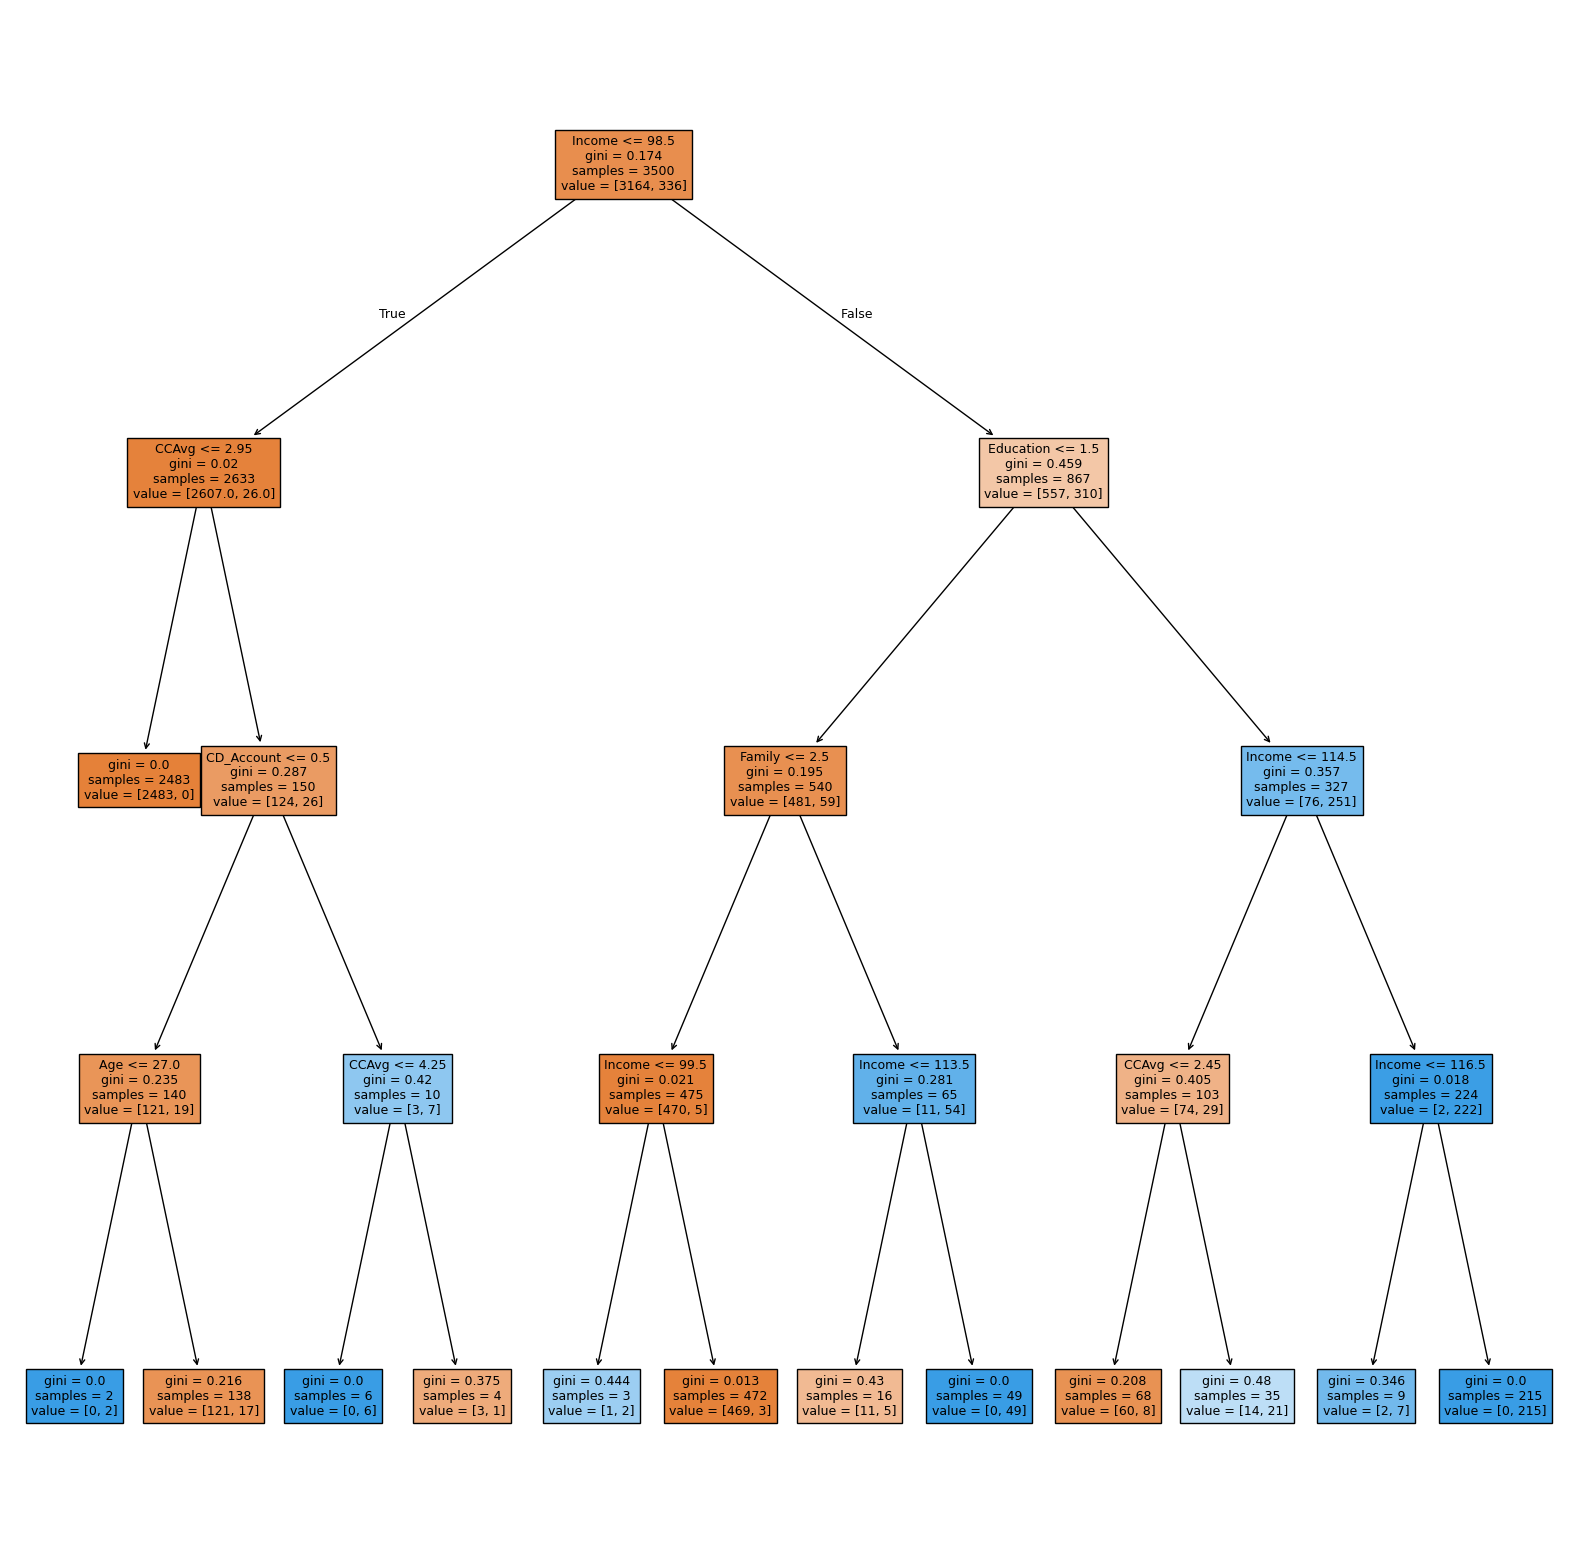

In [ ]:
# list of feature names in X_train
feature_names = list(X_train.columns)

# set the figure size for the plot
plt.figure(figsize=(20, 20))

# plotting the decision tree
out = tree.plot_tree(
    dtree2,                         # decision tree classifier model
    feature_names=feature_names,    # list of feature names (columns) in the dataset
    filled=True,                    # fill the nodes with colors based on class
    fontsize=9,                     # font size for the node text
    node_ids=False,                 # do not show the ID of each node
    class_names=None,               # whether or not to display class names
)

# add arrows to the decision tree splits if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    # set arrow color to black
        arrow.set_linewidth(1)          # set arrow linewidth to 1

# displaying the plot
plt.show()

## Model Performance Comparison and Final Model Selection

#### Observations on pruned Decision tree and Final Model Selection:

* *The **Baseline Decision Tree** model achieved very high metrics on the training set (perfect accuracy, recall, precision, and f1 score) indicating significant overfitting.*

* *The **Pruned Decision Tree** model while having slightly lower performance on the training set shows improved generalization on the test set by it's performance metrics on the test set.*

* *Compared to the highly complex and deep baseline tree, the pruned Decision Tree is significantly simpler and more interpretable due to the constraints on "max_depth", "max_leaf_nodes", and "min_samples_split". This simplified structure helps in understanding the key decision rules the model used to classify customers.*

* *Features like "Income" and "CCAvg" are still prominent which are appearing higher in the tree confirming their importance.*

* *The reduced depth and fewer nodes make it easier to trace paths and extract business rules.*

* *This simpler structure indicates better generalization*

**Conclusion**: *The* **Pruned Decision Tree** *is the preferred model. It successfully addresses the overfitting issue of the baseline model by controlling complexity leading to better and more reliable performance on new unseen data(test set). The improvement in **recall_score** from ~90.97% to ~94.44% is crucial for identifying potential loan buyers and a balanced **f1_score** ensures that the precision is not sacrificed.*

## Actionable Insights and Business Recommendations


**Based on exploratory data analysis and model building key insights and actionable recommendations for AllLife Bank is as follows:**

1. **Target High-Income, High-Spending Customers**: *Customers with higher incomes and higher average credit card spending ("CCAvg") are significantly more likely to accept personal loans. Marketing campaigns should heavily focus on this segment.*
    *   **Recommendation**: *Develop targeted marketing materials and exclusive loan offers for customers in higher income brackets and those with substantial credit card usage.*

2. **Leverage Existing CD Account Holders**: *Customers who already have a Certificate of Deposit (CD) account with the bank show a much higher propensity to take a personal loan. This indicates a segment that trusts the bank and is engaged with its financial products.*
    * **Recommendation**: *Selling personal loans to existing CD account holders through personalized communications may be by offering preferred rates or streamlined application processes.*

3. **Considering Education Level**: *Customers with graduate or advanced/professional education levels are more likely to accept personal loans than undergraduates.*
    * **Recommendation**: *Developing marketing messages to resonate with the financial needs of more educated customer segments.*

4. **Age and Experience as Supporting Factors**: *While "Age" and "Experience" do not have a strong direct linear correlation with personal loan acceptance they are highly correlated with Income. "Age" and "Experience" might play an indirect role in identifying mature customers who are more financially stable.*
    * **Recommendation**: *Use "Age" and "Experience" in conjunction with "Income" and "CCAvg" to refine customer segments particularly for segmenting customers for different loan product types or risk assessment.*

5. **Focus on Specific Needs like Mortgage**: *The "Mortgage" feature showed some correlation suggesting that customers with higher mortgage values might also be good candidates for personal loans (e.g. for home improvements or consolidation).*
    * **Recommendation**: *Explore events or stages where customers might need additional funds such as homeownership various stages/events and offer relevant loan products.*

6. **Avoid over-reliance on Securities Account, Online Banking, and Credit Card (Other Banks)**: *These features showed very weak or negligible correlation with personal loan acceptance. Spending marketing effort based on these attributes might not yield high conversion rates.*
    * **Recommendation**: *Prioritize the strong predictors and allocate marketing resources more efficiently. These features can be secondary filters but should not be primary targeting criteria.*

7. **Data-Driven Campaign Optimization**: *The developed Decision Tree model provides a data-driven approach to identify potential loan buyers. Continuous monitoring and testing of marketing campaigns based on model predictions will be crucial.*
    * **Recommendation**: *Implement the pruned Decision Tree model to score existing liability customers and prioritize those with a high probability of accepting a personal loan for marketing outreach. Regularly retrain and update the model with new data to maintain its effectiveness.*